In [66]:
import logging
import math
import os
import tempfile

import pandas as pd
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed

from tsfm_public import TimeSeriesPreprocessor, get_datasets
from tsfm_public.models.tinytimemixer import (
    TinyTimeMixerConfig,
    TinyTimeMixerForPrediction,
)
from tsfm_public.models.tinytimemixer.utils import get_ttm_args
from tsfm_public.toolkit.get_model import get_model
from tsfm_public.toolkit.lr_finder import optimal_lr_finder
from tsfm_public.toolkit.visualization import plot_predictions
from tsfm_public.toolkit.dataset import ForecastDFDataset

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [67]:
# TTM model path
#TTM_MODEL_PATH = "/Users/annadu/Documents/granite-tsfm/tmp/TTM_cl-512_fl-96_pl-64_apl-3_ne-25_es-True/ttm_pretrained"
TTM_MODEL_PATH = "/Users/andrew/Python/Time Series Forecasting/ttm_pretrained"
SEED = 42
set_seed(SEED)
CONTEXT_LENGTH=90
PREDICTION_LENGTH=30

In [68]:
from argparse import Namespace

args = Namespace(
    forecast_length=PREDICTION_LENGTH,
    context_length=CONTEXT_LENGTH,
    patch_length=16,
    adaptive_patching_levels=2,
    d_model=64,
    decoder_d_model=64,
    num_layers=3,
    decoder_num_layers=2,
    dropout=0.1,
    head_dropout=0.1,
    batch_size=32,
    num_epochs=10,
    learning_rate=1e-3,
    num_workers=2,
    random_seed=42,
    save_dir="checkpoints",
    data_root_path="datasets/",
    dataset="etth1",
    early_stopping=True,
    freeze_backbone=False,
    enable_prefix_tuning=False,
    hf_model_path=None,
)

# Data Processing

In [69]:
# Dataset
TARGET_DATASET = "hdd"
#dataset_path = "/Users/annadu/Documents/granite-tsfm/notebooks/hfdemo/dataset/HDDCURVE_IV.csv" 
dataset_path = '/Users/andrew/Python/Time Series Forecasting/HDDCURVE_IV.csv'
timestamp_column = "date"
id_columns = ["ID"]  # mention the ids that uniquely identify a time-series.
target_columns = ["ship"]
# split_config = {
#         "train": [0, 200],
#         "valid": [200, 225],
#         "test": [225,270],
# }


data = pd.read_csv(
    dataset_path,
    delimiter=";",
    parse_dates=[timestamp_column],
)
##filter down to 1 ID for predictions
data=data[data.ID=='HDD'].drop_duplicates()
print(data.shape)
column_specifiers = {
    "timestamp_column": timestamp_column,
    "id_columns": id_columns,
    "target_columns": target_columns,
    "control_columns": [],
}

tsp = TimeSeriesPreprocessor(
    timestamp_column=timestamp_column,
    id_columns=id_columns,
    target_columns=target_columns,
    scaling=True,
)

tsp.train(data) ##should we be training on a different dataset?

#df=data.copy()
data = ForecastDFDataset(
    tsp.preprocess(data),
    id_columns=id_columns,
    target_columns=target_columns,
    context_length=CONTEXT_LENGTH,
    prediction_length=PREDICTION_LENGTH
)

## use this to look at df in processed data
#x=data.datasets[0].data_df
#x

(250, 3)


/var/folders/p2/cw01s4hx5ydcf0znwv067t800000gn/T/ipykernel_38554/1461220330.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(


In [70]:
## Run the following cell when you have a model trained for 90/30. 
## If not, run the next cell
##you can see the context_len and forecast_len in the output if you aren't sure

model=get_model(TTM_MODEL_PATH)
temp_dir = tempfile.mkdtemp()
trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir=temp_dir,
            per_device_eval_batch_size=args.batch_size,
            seed=args.random_seed,
            report_to="none",
        ))

INFO:p-38554:t-8642498368:get_model.py:get_model:Loading model from: /Users/andrew/Python/Time Series Forecasting/ttm_pretrained
INFO:p-38554:t-8642498368:get_model.py:get_model:Model loaded successfully!
INFO:p-38554:t-8642498368:get_model.py:get_model:[TTM] context_len = 512, forecast_len = 96


In [71]:
## Run this code to import base model with custom config
from tsfm_public.models.tinytimemixer import TinyTimeMixerConfig, TinyTimeMixerForPrediction

# Create a custom config for the model
custom_config = TinyTimeMixerConfig(
    context_length=CONTEXT_LENGTH,  # Override context length
    prediction_length=PREDICTION_LENGTH,  # Override forecast length
    # Other configurations if necessary
)

# Load the model using the custom configuration
model = TinyTimeMixerForPrediction(custom_config)

# Now you can continue with your trainer and training process
trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir=temp_dir,
        per_device_eval_batch_size=args.batch_size,
        seed=args.random_seed,
        report_to="none",
    )
)

In [72]:
predictions=trainer.predict(data)
predictions=predictions.predictions

  0%|          | 0/5 [00:00<?, ?it/s]

In [73]:
for i in range(5):
    print(f"Len predictions[{i}]:", len(predictions[i])) 

Len predictions[0]: 131
Len predictions[1]: 131
Len predictions[2]: 131
Len predictions[3]: 131
Len predictions[4]: 131


### Plot True Values

<Axes: xlabel='step', ylabel='ship'>

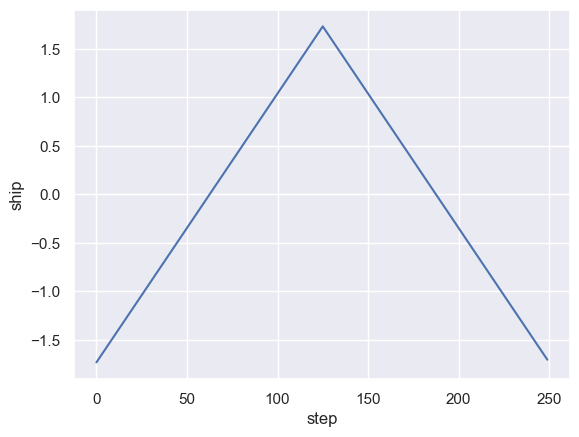

In [74]:
gt=data.datasets[0].data_df.copy()
gt=gt.reset_index(names='step')
sns.lineplot(data=gt, x='step', y='ship')

### Plot Predicted Values

In [76]:
preds

,step,0,1,2,3,4,5,6,7,8,...,20,21,22,23,24,25,26,27,28,29
0,91,-0.410356,-0.683682,-0.403466,-0.347389,-0.462222,-0.676966,-0.306737,-0.445567,-0.414124,...,-0.641195,-0.583307,-0.626260,-0.455146,-0.794897,-0.721238,-0.580175,-0.434590,-0.334271,-0.611498
1,92,-0.382645,-0.655971,-0.375755,-0.319679,-0.434511,-0.649255,-0.279026,-0.417856,-0.386413,...,-0.613484,-0.555596,-0.598549,-0.427435,-0.767186,-0.693528,-0.552464,-0.406879,-0.306560,-0.583787
2,93,-0.354934,-0.628260,-0.348044,-0.291967,-0.406800,-0.621544,-0.251315,-0.390145,-0.358702,...,-0.585773,-0.527885,-0.570838,-0.399724,-0.739475,-0.665816,-0.524753,-0.379167,-0.278849,-0.556076
3,94,-0.327223,-0.600549,-0.320333,-0.264256,-0.379089,-0.593833,-0.223604,-0.362434,-0.330991,...,-0.558062,-0.500174,-0.543127,-0.372013,-0.711764,-0.638106,-0.497042,-0.351456,-0.251138,-0.528365
4,95,-0.299512,-0.572838,-0.292622,-0.236545,-0.351378,-0.566122,-0.195893,-0.334723,-0.303279,...,-0.530351,-0.472463,-0.515416,-0.344302,-0.684053,-0.610394,-0.469331,-0.323745,-0.223427,-0.500654
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,217,0.263852,0.674053,0.297948,0.274442,0.516099,0.451193,0.542456,0.673248,0.503476,...,0.452593,0.911362,0.474154,0.418066,0.355608,0.529910,0.285933,0.527315,0.407376,0.563340
127,218,0.236141,0.646342,0.270237,0.246731,0.488387,0.423482,0.514745,0.645537,0.475765,...,0.424882,0.883651,0.446443,0.390355,0.327897,0.502199,0.258222,0.499604,0.379665,0.535629
128,219,0.208430,0.618631,0.242526,0.219020,0.460676,0.395771,0.487034,0.617826,0.448054,...,0.397171,0.855940,0.418732,0.362644,0.300186,0.474488,0.230511,0.471893,0.351954,0.507918
129,220,0.180719,0.590920,0.214815,0.191309,0.432965,0.368060,0.459323,0.590115,0.420343,...,0.369460,0.828229,0.391020,0.334933,0.272475,0.446777,0.202800,0.444182,0.324242,0.480207


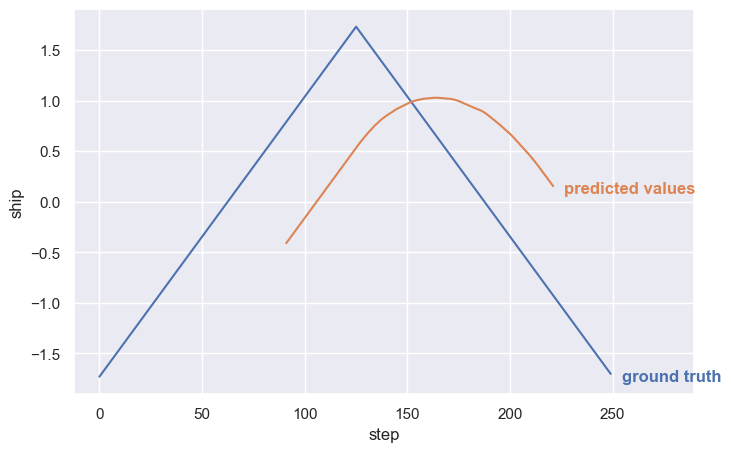

In [75]:
preds=pd.DataFrame(predictions[0].reshape(predictions[0].shape[0],predictions[0].shape[1]))
preds=preds.reset_index(names='step')
preds['step']=preds.step+CONTEXT_LENGTH+1
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=gt, x='step', y='ship', ax=ax)
sns.lineplot(data=preds, x='step', y=0, ax=ax)
labels=['ground truth', 'predicted values']
for line, name in zip(ax.lines, labels):
    y = line.get_ydata()[-1]
    x = line.get_xdata()[-1]
    if not np.isfinite(y):
        y = next(reversed(line.get_ydata()[~line.get_ydata().mask]), float("nan"))
    if not np.isfinite(y) or not np.isfinite(x):
        continue     
    text = ax.annotate(name,
                       xy=(x, y),
                       xytext=(8,-5), ##adjust offset
                       color=line.get_color(),
                       xycoords=(ax.get_xaxis_transform(), ax.get_yaxis_transform()),
                       textcoords="offset points",
                       fontweight='bold')
    text_width = (text.get_window_extent(ax.figure.canvas.get_renderer()).transformed(ax.transData.inverted()).width)
    if np.isfinite(text_width):
        ax.set_xlim(ax.get_xlim()[0], text.xy[0] + text_width * 1.05)
plt.show()

In [ ]:
predictions[1].shape

(131, 1, 11, 16)

In [ ]:
target=pd.DataFrame(predictions[1].reshape(predictions[1].shape[0], -1))
target

,0,1,2,3,4,5,6,7,8,9,...,166,167,168,169,170,171,172,173,174,175
0,-0.994686,-1.325660,0.073019,1.801992,-1.376913,-0.898750,0.37645,0.040746,-0.485144,0.108197,...,-0.461995,-0.411707,-0.093481,-0.725568,-0.390046,-0.252019,-1.060424,-1.628766,-1.753639,-2.398233
1,-0.994686,-1.325660,0.073019,1.801992,-1.376913,-0.898750,0.37645,0.040746,-0.485144,0.108197,...,-0.461995,-0.411707,-0.093481,-0.725568,-0.390046,-0.252019,-1.060424,-1.628766,-1.753639,-2.398233
2,-0.994686,-1.325660,0.073019,1.801992,-1.376914,-0.898750,0.37645,0.040746,-0.485144,0.108197,...,-0.461995,-0.411707,-0.093481,-0.725568,-0.390046,-0.252019,-1.060424,-1.628766,-1.753639,-2.398233
3,-0.994686,-1.325660,0.073019,1.801992,-1.376914,-0.898750,0.37645,0.040746,-0.485144,0.108197,...,-0.461995,-0.411707,-0.093481,-0.725568,-0.390046,-0.252019,-1.060424,-1.628766,-1.753639,-2.398233
4,-0.994686,-1.325661,0.073019,1.801992,-1.376914,-0.898750,0.37645,0.040746,-0.485144,0.108197,...,-0.461995,-0.411707,-0.093481,-0.725568,-0.390045,-0.252019,-1.060424,-1.628766,-1.753639,-2.398233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,1.698402,1.245010,0.605072,-1.505983,0.816597,1.477212,-0.48949,-0.234819,-0.051880,-0.754883,...,0.191923,0.061721,-0.603986,-0.073835,0.566679,0.042496,1.202583,0.967618,2.113386,1.689804
127,1.698402,1.245010,0.605072,-1.505983,0.816598,1.477212,-0.48949,-0.234819,-0.051880,-0.754883,...,0.191923,0.061721,-0.603986,-0.073836,0.566679,0.042496,1.202583,0.967618,2.113386,1.689804
128,1.698402,1.245010,0.605072,-1.505983,0.816598,1.477212,-0.48949,-0.234819,-0.051880,-0.754883,...,0.191923,0.061721,-0.603986,-0.073835,0.566679,0.042496,1.202583,0.967618,2.113386,1.689804
129,1.698402,1.245010,0.605072,-1.505983,0.816598,1.477212,-0.48949,-0.234819,-0.051880,-0.754883,...,0.191923,0.061721,-0.603986,-0.073835,0.566679,0.042496,1.202583,0.967618,2.113386,1.689804


In [ ]:
##I thought predictions[1] would contain the target data, but it doesn't seem to match any values there
##Only looking for it here because I can't tell what index the predictions align to
t=data.datasets[0].data_df
t[t.ship==target.loc[0,0]]

,ID,date,ship
